# Predicting loan amount for accepted LendingClub applications

**Data Visualization project, Part A, steps 1 to 5:** dataset, load, pre-cleaning insights, cleaning, and before/after visuals.

This notebook goes from the raw Kaggle file to a cleaned table. Steps 6 to 9 (ML direction, feature selection, decision table, dashboard) start from that table.

**To run it**

1. Download `accepted_2007_to_2018Q4.csv.gz` from <https://www.kaggle.com/datasets/wordsforthewise/lending-club> (Kaggle login needed) and put it in `data/raw/`.
2. Install the packages in `requirements.txt`.
3. Run all cells from top to bottom. The whole notebook takes about three minutes on a 16 GB laptop; the load alone is over a minute.

**What it writes**

| File | What it is | In git? |
|---|---|---|
| `data/processed/loans_clean.parquet` | The cleaned table, one row per loan | No (too large; re-create it by running this notebook) |
| `outputs/column_tags.csv` | Every cleaned column with its role (target, leakage, LC pricing, post-issue, application-time) | Yes |
| `outputs/figures/*.png` | The charts below, for slides and the report | Yes |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "accepted_2007_to_2018Q4.csv.gz"
CLEAN_PATH = ROOT / "data" / "processed" / "loans_clean.parquet"
TAGS_PATH = ROOT / "outputs" / "column_tags.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

TARGET = "loan_amnt"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

# One look for every chart: blue for the main series, orange for the comparison series.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUES = LinearSegmentedColormap.from_list("blues", [SURFACE, "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "legend.frameon": False,
})


def save(fig, name):
    """Save a chart to outputs/figures for slides and the report."""
    fig.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")


print("pandas", pd.__version__, "| data file found:", DATA_PATH.exists())

pandas 3.0.3 | data file found: True


## 1. Dataset, motivation and complexity

Every number in this section is measured further down; the section that produces it is named in brackets.

### 1.1 The question and who cares

**Main question: what determines how much an accepted LendingClub borrower takes out, and can we predict `loan_amnt`?**

Sub-questions the dashboard will answer:

- Which borrower traits go with larger loans (income, existing debt, credit history, home ownership)?
- How did loan size change between 2007 and 2018?
- How does loan size differ by purpose and by state?

Who cares:

- **A lender** wants to anticipate how much a new applicant will ask for, to plan funding and to make pre-qualified offers.
- **A borrower** wants to know what people in a similar position borrow.

### 1.2 Source and provenance

- LendingClub was a US peer-to-peer lender: people applied for unsecured personal loans and investors funded them. It published loan-level data for those investors. The Kaggle dataset `wordsforthewise/lending-club` is an archived copy of those files.
- LendingClub closed its investor (Notes) platform on 31 December 2020, so the series is complete and no longer updated at the source ([Finextra](https://www.finextra.com/pressarticle/84439/lendingclub-sunsets-notes-platform), [Banking Dive](https://bankingdive.com/news/lendingclub-peer-to-peer-loans/586841)).
- Coverage: loans issued from June 2007 to December 2018 [2.4]. One row is one issued loan.
- The file is a snapshot taken around March 2019: the most common last-payment month is Mar-2019 [2.2]. Loans issued late in the period were still being repaid at that point.

### 1.3 Size and features

- 393 MB compressed, 2,260,701 rows and 151 columns, 3.3 GB once loaded [2.1].
- 113 columns are numeric and 38 are text [2.1].
- 33 rows are not loans but summary lines left over from the quarterly files, so the file holds 2,260,668 loans [2.3].
- The 151 columns fall into seven kinds of information [2.5]:

| Group | Columns | What it holds |
|---|---|---|
| Credit bureau file | 69 | The borrower's credit report at application: accounts, balances, limits, delinquencies, FICO range |
| Loan terms and listing | 19 | Amount, term, rate, grade, purpose, issue date |
| Post-issue performance | 17 | What happened after the loan was issued: status, payments, recoveries |
| Joint / second applicant | 16 | Income, DTI and credit details of a co-borrower |
| Hardship plan | 15 | Details of payment-relief plans |
| Borrower profile | 8 | Job title, employment length, income, home ownership, state, DTI |
| Debt settlement | 7 | Details of settled debts |

### 1.4 Why this dataset

- **Real and large.** 2.26 million real loans, not a synthetic or toy file. The pandas load takes over a minute on a laptop, so GPU acceleration has something to speed up.
- **Mixed data types.** Numbers, categories, dates stored as text, free text and geography in one table, which supports varied chart types and a state map in Tableau.
- **Twelve years of history.** Yearly volume grows from 603 loans in 2007 to 495,242 in 2018 [2.4], so there is a time story.
- **Untidy in ways that need real cleaning.** See 1.6.
- **Why the accepted file only.** The same Kaggle dataset has a rejected-applications file, but it has only 9 columns (amount requested, application date, loan title, risk score, DTI, zip code, state, employment length, policy code). It has no income and no credit history, so it cannot support a question about what drives loan size. (Checked by reading the header of `rejected_2007_to_2018Q4.csv.gz`.)

### 1.5 Why loan amount as the target

- `loan_amnt` is a dollar amount, so the Part B task is **regression**. Most projects on this dataset predict default instead; loan size is a less worn question.
- What it records: the amount the borrower applied for, lowered if LendingClub's credit department reduced it (LendingClub data dictionary). So the target mixes what the borrower wanted with what the lender allowed, and we say so openly.
- It is complete: every one of the 2,260,668 loans has a value, from \$500 to \$40,000 [2.2].

### 1.6 Data complexity

- **Volume and width:** 2.26M rows by 151 columns, 3.3 GB in memory [2.1].
- **Missing values with structure, not random gaps:** 58 of 151 columns are more than 30% empty, and nothing sits between 13% and 38% [3.2]. Whole blocks of columns only exist from 2012, from December 2015 or from 2017, because LendingClub added fields over time [3.3]. Joint-applicant, hardship and settlement columns apply to under 6% of loans.
- **Numbers and dates stored as text:** `term` is `" 36 months"`, `emp_length` is `"10+ years"`, dates are `"Dec-2015"` [3.6].
- **High-cardinality free text:** `emp_title` has 512,694 distinct values [2.2].
- **Summary rows mixed into the data:** 33 of them [2.3].
- **Extreme values:** `annual_inc` reaches \$110 million and `dti` reaches 999 [3.4]. The broken `dti` and zero-income values all belong to joint applications, where the individual field is not the one LendingClub used.
- **Empty, constant and redundant columns:** `member_id` is empty, `policy_code` is always 1, and `fico_range_high` is always `fico_range_low` plus 4 or 5 [3.7].

### 1.7 Problem complexity

- **Heaped target:** borrowers pick round numbers. 70% of loans are an exact multiple of \$1,000 and 34% a multiple of \$5,000 [3.5].
- **Bounded target, and the bound moved:** the maximum was \$25,000 until 2010, \$35,000 from 2011 and \$40,000 from March 2016 [3.5]. Reported at the time by [PR Newswire](https://www.prnewswire.com/news-releases/lending-club-increases-maximum-personal-loan-size-to-35000-116217554.html) and [deBanked](https://debanked.com/2016/03/lending-club-loan-size-cap-raised-to-40000-should-investors-be-worried/).
- **Leakage in three forms** [3.7]:
  - restatements of the target: `funded_amnt` equals `loan_amnt` in 99.9% of loans, and `installment` is computed from it;
  - post-issue outcomes: payments, recoveries, loan status, which do not exist when the amount is decided;
  - lender pricing: grade and interest rate, which LendingClub sets knowing the amount.
- **Selection:** the file holds accepted loans only, so conclusions do not extend to everyone who applied.
- **Drift:** twelve years in which volume, the borrower mix and the platform's rules all changed [2.4].
- **Part of the amount is personal choice.** Two people with the same profile can want different amounts, so we should expect moderate, not high, accuracy from application-time features. Saying this up front sets a fair bar for Part B.

### 1.8 Complexity scorecard

The scorecard table is built from the data at the end of section 3 [3.8], so its numbers cannot drift from the notebook.

## 2. Load the dataset

### 2.1 Full load, timed

The whole file is read with pandas. `low_memory=False` makes pandas decide each column's type from the full column instead of chunk by chunk, which avoids mixed-type warnings.

In [2]:
t0 = time.perf_counter()
df = pd.read_csv(DATA_PATH, low_memory=False)
load_seconds = time.perf_counter() - t0

n_rows_raw, n_cols_raw = df.shape
mem_gb_raw = df.memory_usage(deep=True).sum() / 1e9
dtypes_raw = df.dtypes.astype(str).value_counts()

print(f"File on disk : {DATA_PATH.stat().st_size / 1e6:,.0f} MB (gzip)")
print(f"Load time    : {load_seconds:,.0f} s with pandas {pd.__version__} on CPU")
print(f"Shape        : {n_rows_raw:,} rows x {n_cols_raw} columns")
print(f"In memory    : {mem_gb_raw:.2f} GB")
print(f"Column types : {dtypes_raw.to_dict()}")

File on disk : 393 MB (gzip)
Load time    : 84 s with pandas 3.0.3 on CPU
Shape        : 2,260,701 rows x 151 columns
In memory    : 3.29 GB
Column types : {'float64': 113, 'str': 38}


### 2.2 First inspection

Nothing is assumed about the columns. The next four outputs are the basis for everything said about the data later: non-null counts and types for all 151 columns, the first rows, and summary statistics for the numeric and the text columns.

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  str    
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  str    
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  str    
 9    sub_grade                                   2260668 non

In [4]:
# First three rows, turned sideways so all 151 columns are visible.
df.head(3).T

,0,1,2
id,68407277,68355089,68341763
member_id,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0
funded_amnt,3600.0,24700.0,20000.0
funded_amnt_inv,3600.0,24700.0,20000.0
term,36 months,36 months,60 months
int_rate,13.99,11.99,10.78
installment,123.03,820.28,432.66
grade,C,C,B
sub_grade,C4,C1,B4


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.93,9190.25,500.00,8000.00,12900.00,20000.00,4.000000e+04
funded_amnt,2260668.0,15041.66,9188.41,500.00,8000.00,12875.00,20000.00,4.000000e+04
funded_amnt_inv,2260668.0,15023.44,9192.33,0.00,8000.00,12800.00,20000.00,4.000000e+04
int_rate,2260668.0,13.09,4.83,5.31,9.49,12.62,15.99,3.099000e+01
installment,2260668.0,445.81,267.17,4.93,251.65,377.99,593.32,1.719830e+03
annual_inc,2260664.0,77992.43,112696.20,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.82,14.18,-1.00,11.89,17.84,24.49,9.990000e+02
delinq_2yrs,2260639.0,0.31,0.87,0.00,0.00,0.00,0.00,5.800000e+01
fico_range_low,2260668.0,698.59,33.01,610.00,675.00,690.00,715.00,8.450000e+02


In [6]:
df.describe(exclude="number").T

,count,unique,top,freq
id,2260701,2260701,68407277,1
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1076751


**What these outputs show**

- **Target.** `loan_amnt` runs from \$500 to \$40,000 with a median of \$12,900 and a mean of \$15,047. `funded_amnt` has almost the same statistics.
- **33 rows are not loans.** `id` is filled in all 2,260,701 rows but no other column is filled in more than 2,260,668 (checked in 2.3).
- **Empty and constant columns.** `member_id` has no values. `policy_code` is 1 everywhere. `hardship_type` has one value.
- **Columns that apply to few loans.** Joint-applicant fields have about 120,000 values, settlement fields 34,246 and hardship fields 10,917, out of 2.26 million.
- **Blocks with the same count.** Thirteen credit-bureau columns from `open_acc_6m` to `inq_last_12m` all have about 1.39 million values, which points to fields added partway through the period (tested in 3.3).
- **Text that should be numbers or dates.** `term`, `emp_length`, `issue_d`, `earliest_cr_line`.
- **Free text.** `emp_title` has 512,694 distinct values, `title` 63,154.
- **Implausible extremes.** `annual_inc` goes up to 110,000,000, `dti` from -1 to 999, `revol_util` up to 892%.
- **Snapshot date.** The most common `last_pymnt_d` is Mar-2019 and the most common `next_pymnt_d` is Apr-2019.

### 2.3 Rows that are not loans

In [7]:
not_loan = df[TARGET].isna()
loans = ~not_loan
n_summary_rows = int(not_loan.sum())

print(f"Rows without a loan amount            : {n_summary_rows}")
print(f"Filled cells in them, other than `id` : {df.loc[not_loan].drop(columns='id').notna().sum().sum()}")
print(f"Loans in the file                     : {loans.sum():,}")
df.loc[not_loan, ["id"]].head(6)

Rows without a loan amount            : 33
Filled cells in them, other than `id` : 0
Loans in the file                     : 2,260,668


,id
421095,Total amount funded in policy code 1: 6417608175
421096,Total amount funded in policy code 2: 1944088810
528961,Total amount funded in policy code 1: 1741781700
528962,Total amount funded in policy code 2: 564202131
651664,Total amount funded in policy code 1: 1791201400
651665,Total amount funded in policy code 2: 651669342


The 33 rows carry a sentence in the `id` column ("Total amount funded in policy code 1: ...") and nothing else. They are the totals lines at the end of each quarterly file that was stacked to make this one. They are removed in step 4.

### 2.4 Duplicates, date range and volume by year

In [8]:
n_duplicate_ids = int(df.loc[loans, "id"].duplicated().sum())
issue_date = pd.to_datetime(df["issue_d"], format="%b-%Y")

print(f"Duplicate loan ids : {n_duplicate_ids}")
print(f"Issue dates        : {issue_date.min():%b %Y} to {issue_date.max():%b %Y} ({issue_date.nunique()} months)")

by_year = df.groupby(issue_date.dt.year)[TARGET].agg(loans="size", median="median", mean="mean", max="max")
by_year.index = by_year.index.astype(int)
by_year.index.name = "issue year"
by_year.round(0).astype(int)

Duplicate loan ids : 0
Issue dates        : Jun 2007 to Dec 2018 (139 months)


,loans,median,mean,max
issue year,,,,
2007,603,6000,8255,25000
2008,2393,7500,8825,25000
2009,5281,8800,9833,25000
2010,12537,9300,10528,25000
2011,21721,10000,12048,35000
2012,53367,12000,13462,35000
2013,134814,13000,14707,35000
2014,235629,13000,14870,35000
2015,421095,14000,15240,35000


- No loan appears twice.
- Volume grows from 603 loans in 2007 to 495,242 in 2018. 2015 to 2018 hold 79% of all loans, so any overall average is mostly about those four years.
- The largest loan steps up from \$25,000 to \$35,000 in 2011 and to \$40,000 in 2016. That is a policy limit, looked at more closely in 3.5.

### 2.5 What the 151 columns describe

Each column is assigned to one of seven groups by name. The check at the end fails if any column is left out, named twice or misspelled, so nothing can be filed silently.

In [9]:
cols = list(df.columns)


def block(first, last):
    """Columns from `first` to `last` inclusive, in file order."""
    return cols[cols.index(first): cols.index(last) + 1]


GROUPS = {
    "Loan terms and listing": [
        "id", "member_id", "loan_amnt", "funded_amnt", "funded_amnt_inv", "term", "int_rate", "installment",
        "grade", "sub_grade", "issue_d", "url", "desc", "purpose", "title", "initial_list_status",
        "policy_code", "application_type", "disbursement_method",
    ],
    "Borrower profile": [
        "emp_title", "emp_length", "home_ownership", "annual_inc", "verification_status",
        "zip_code", "addr_state", "dti",
    ],
    "Credit bureau file": (
        block("delinq_2yrs", "total_acc")
        + ["collections_12_mths_ex_med", "mths_since_last_major_derog"]
        + block("acc_now_delinq", "total_il_high_credit_limit")
    ),
    "Post-issue performance": ["loan_status", "pymnt_plan"] + block("out_prncp", "last_fico_range_low"),
    "Joint / second applicant": (
        block("annual_inc_joint", "verification_status_joint")
        + block("revol_bal_joint", "sec_app_mths_since_last_major_derog")
    ),
    "Hardship plan": block("hardship_flag", "hardship_last_payment_amount"),
    "Debt settlement": block("debt_settlement_flag", "settlement_term"),
}

assigned = [c for members in GROUPS.values() for c in members]
unassigned = [c for c in cols if c not in assigned]
named_twice = sorted({c for c in assigned if assigned.count(c) > 1})
print(f"Columns assigned: {len(assigned)} of {len(cols)} | unassigned: {unassigned} | named twice: {named_twice}")
assert not unassigned and not named_twice and len(assigned) == len(cols)

group_of = pd.Series({c: g for g, members in GROUPS.items() for c in members}, name="group")
kind = df.dtypes.map(pd.api.types.is_numeric_dtype).map({True: "numeric", False: "text"})
# Share of missing values per column, measured over the loans (the 33 summary rows are left out).
null_pct_raw = df.isna().loc[loans].mean().mul(100)

group_table = pd.crosstab(group_of, kind.reindex(group_of.index).values)
group_table.insert(0, "columns", group_table.sum(axis=1))
group_table["median % missing"] = null_pct_raw.groupby(group_of).median().round(1)
group_table = group_table.sort_values("columns", ascending=False)
group_table.index.name, group_table.columns.name = "group", None
group_table

Columns assigned: 151 of 151 | unassigned: [] | named twice: []


,columns,numeric,text,median % missing
group,,,,
Credit bureau file,69,68,1,3.1
Loan terms and listing,19,7,12,0.0
Post-issue performance,17,12,5,0.0
Joint / second applicant,16,14,2,95.2
Hardship plan,15,7,8,99.5
Borrower profile,8,2,6,0.0
Debt settlement,7,3,4,98.5


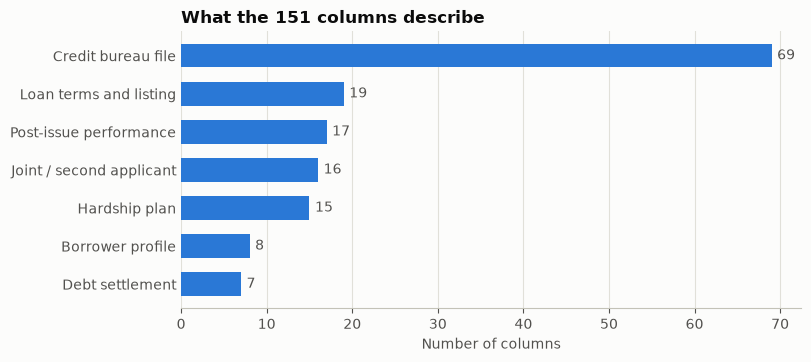

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))
plot = group_table["columns"].sort_values()
bars = ax.barh(plot.index, plot.values, color=BLUE, height=0.62)
ax.bar_label(bars, padding=4, color=INK2)
ax.set_title(f"What the {len(cols)} columns describe")
ax.set_xlabel("Number of columns")
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "01_feature_groups.png")
plt.show()

- Almost half the columns (69) are the borrower's credit report.
- Only 8 columns describe the borrower directly, and a few loan-listing columns (purpose, issue date, application type) are also known at application.
- 55 columns (post-issue, joint, hardship, settlement) either describe what happened after the loan was issued or apply to a small share of loans. The joint, hardship and settlement groups are almost entirely empty (median missing above 95%).

## 3. Pre-cleaning insights

Each part looks at the raw data and ends with the cleaning action it leads to. Nothing is changed in this section.

### 3.1 Volume over time

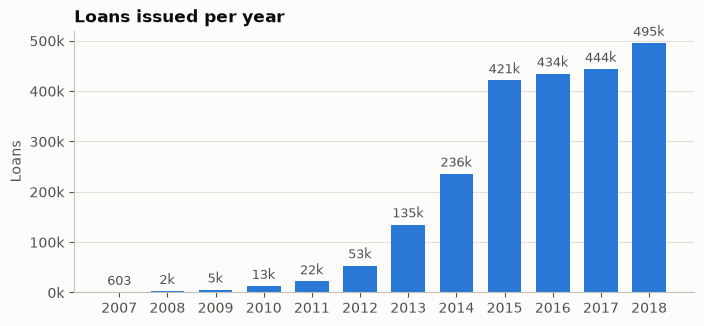

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(by_year.index.astype(str), by_year["loans"], color=BLUE, width=0.7)
ax.bar_label(bars, labels=[f"{v / 1000:,.0f}k" if v >= 1000 else f"{v}" for v in by_year["loans"]],
             padding=3, color=INK2, fontsize=9)
ax.set_title("Loans issued per year")
ax.set_ylabel("Loans")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f}k")
ax.grid(axis="x", visible=False)
save(fig, "03_loans_per_year.png")
plt.show()

The platform grew almost every year, and the last four years dominate the file. **For cleaning:** rows from the early years must not be thrown away just because they lack fields that were added later, or the time story is lost.

### 3.2 Missing values by column

In [12]:
miss = null_pct_raw.sort_values(ascending=False)
BAND_EDGES = [-0.001, 0, 15, 50, 90, 100]
BAND_LABELS = ["none", "up to 15%", "15% to 50%", "50% to 90%", "over 90%"]
bands_before = pd.cut(miss, BAND_EDGES, labels=BAND_LABELS).value_counts().reindex(BAND_LABELS)

THRESHOLD = 30  # percent missing above which a column is dropped in step 4
n_above = int((miss > THRESHOLD).sum())
largest_kept = miss[miss <= THRESHOLD].max()
smallest_dropped = miss[miss > THRESHOLD].min()

print(f"Cells missing overall: {df.isna().loc[loans].values.mean() * 100:.1f}%")
print(f"Columns more than {THRESHOLD}% missing: {n_above} of {len(miss)}")
print(f"Most-missing column at or below the line: {miss[miss <= THRESHOLD].idxmax()} ({largest_kept:.1f}%)")
print(f"Least-missing column above the line     : {miss[miss > THRESHOLD].idxmin()} ({smallest_dropped:.1f}%)")
bands_before.to_frame("columns")

Cells missing overall: 31.8%
Columns more than 30% missing: 58 of 151
Most-missing column at or below the line: mths_since_recent_inq (13.1%)
Least-missing column above the line     : open_il_24m (38.3%)


,columns
none,38
up to 15%,55
15% to 50%,14
50% to 90%,6
over 90%,38


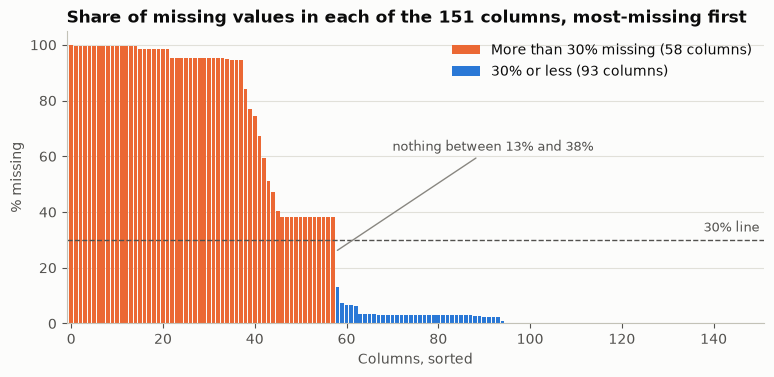

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(miss))
above = miss.values > THRESHOLD
ax.bar(x[above], miss.values[above], width=0.8, color=ORANGE, label=f"More than {THRESHOLD}% missing ({n_above} columns)")
ax.bar(x[~above], miss.values[~above], width=0.8, color=BLUE, label=f"{THRESHOLD}% or less ({len(miss) - n_above} columns)")
ax.axhline(THRESHOLD, color=INK2, lw=1, ls="--")
ax.text(len(miss) - 1, THRESHOLD + 3, f"{THRESHOLD}% line", ha="right", color=INK2, fontsize=9)
ax.annotate(f"nothing between {largest_kept:.0f}% and {smallest_dropped:.0f}%",
            xy=(n_above - 0.5, (largest_kept + smallest_dropped) / 2), xytext=(n_above + 12, 62),
            color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title(f"Share of missing values in each of the {len(miss)} columns, most-missing first")
ax.set_xlabel("Columns, sorted")
ax.set_ylabel("% missing")
ax.set_ylim(0, 105)
ax.set_xlim(-1, len(miss))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
save(fig, "03_missing_by_column.png")
plt.show()

In [14]:
# Which groups do the mostly-empty columns belong to?
above_by_group = pd.DataFrame({
    "columns": group_of.value_counts(),
    f"more than {THRESHOLD}% missing": (miss > THRESHOLD).groupby(group_of).sum(),
}).sort_values("columns", ascending=False)
above_by_group

,columns,more than 30% missing
group,,
Credit bureau file,69,19
Loan terms and listing,19,2
Post-issue performance,17,1
Joint / second applicant,16,16
Hardship plan,15,14
Borrower profile,8,0
Debt settlement,7,6


- The columns split cleanly into two sets: 93 columns with at most 13% missing, and 58 columns with 38% or more. Nothing lies in between, so any threshold between 13% and 38% drops the same columns. We use 30%.
- The mostly-empty columns are the joint-applicant, hardship and settlement details (they apply to few loans), plus part of the credit bureau file.

**For cleaning:** drop the columns above 30%. First check why the credit-bureau ones are empty (3.3) and whether any of the joint columns are needed (3.4).

### 3.3 Missing values by issue year

If a column is empty because LendingClub had not started recording it yet, its missing share will be 100% in early years and then fall to near zero.

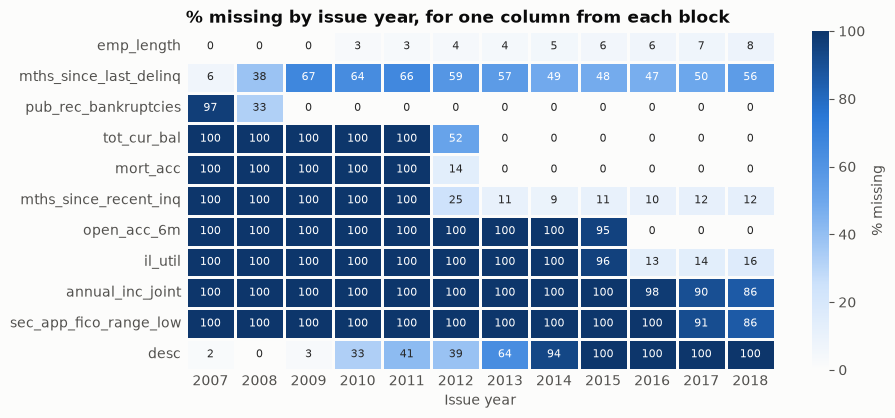

In [15]:
wave_cols = ["emp_length", "mths_since_last_delinq", "pub_rec_bankruptcies", "tot_cur_bal", "mort_acc",
             "mths_since_recent_inq", "open_acc_6m", "il_util", "annual_inc_joint", "sec_app_fico_range_low", "desc"]
miss_by_year = df[wave_cols].isna().groupby(issue_date.dt.year).mean().mul(100).T
miss_by_year.columns = miss_by_year.columns.astype(int)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
sns.heatmap(miss_by_year, cmap=BLUES, vmin=0, vmax=100, annot=True, fmt=".0f", annot_kws={"size": 8},
            linewidths=2, linecolor=SURFACE, cbar_kws={"label": "% missing"}, ax=ax)
ax.set_title("% missing by issue year, for one column from each block")
ax.set_xlabel("Issue year")
ax.set_ylabel("")
ax.tick_params(length=0)
save(fig, "03_missing_by_year.png")
plt.show()

The gaps follow the calendar, not chance:

- `tot_cur_bal` and `mort_acc` (and the blocks they stand for) do not exist before 2012.
- `open_acc_6m` and its block of 13 columns start in December 2015. Before that they are 100% empty.
- Joint-application fields start in late 2015 and second-applicant fields in 2017.
- `desc` goes the other way: borrowers stopped writing descriptions after 2014.
- `mths_since_last_delinq` is about half empty in every year. That is a different kind of gap: the borrower has never been delinquent, so there is no number of months to record.
- `emp_length` is missing for a small, slowly rising share (people who gave no employment).

**For cleaning:**

- The 2015-onward block cannot be filled in for the 38% of loans issued earlier, so it is dropped, not imputed.
- "Months since" columns that are mostly empty are dropped too. An empty value means "never", which no number can stand for, and the count columns (`delinq_2yrs`, `pub_rec`) carry the same information.
- Columns missing only for the pre-2012 loans (about 3% of rows) are kept and filled with the median.

### 3.4 Extreme values

In [16]:
OUTLIER_COLS = ["annual_inc", "dti", "revol_util", "revol_bal"]
quantiles = df[OUTLIER_COLS].quantile([0, 0.01, 0.5, 0.99, 0.999, 1]).T
quantiles.columns = ["min", "1%", "median", "99%", "99.9%", "max"]
quantiles.round(1)

,min,1%,median,99%,99.9%,max
annual_inc,0.0,16800.0,65000.0,270000.0,600000.0,110000000.0
dti,-1.0,1.7,17.8,42.7,106.6,999.0
revol_util,0.0,0.9,50.3,98.1,102.1,892.3
revol_bal,0.0,126.0,11324.0,97930.0,265894.3,2904836.0


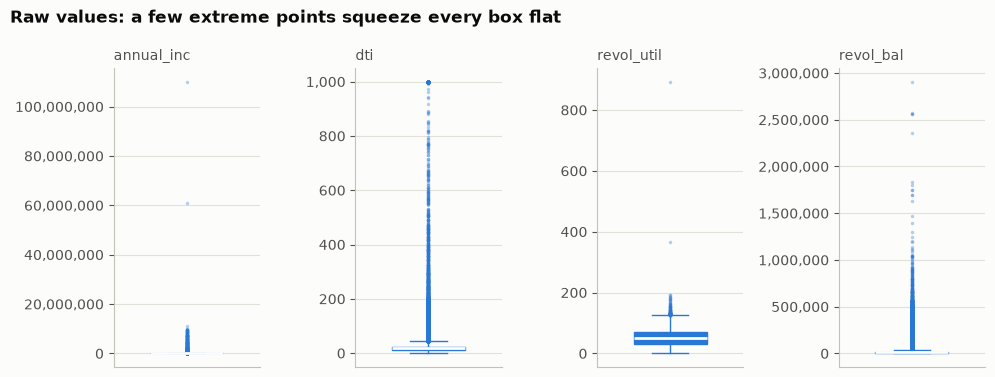

In [17]:
def draw_box(ax, values, color):
    """One box plot, with the points beyond the whiskers drawn as faint dots."""
    ax.boxplot(values, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=color, edgecolor=color), medianprops=dict(color=SURFACE, linewidth=2),
               whiskerprops=dict(color=color), capprops=dict(color=color),
               flierprops=dict(marker="o", markersize=2.5, markerfacecolor=color, markeredgecolor="none", alpha=0.35))
    ax.set_xticks([])
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")


fig, axes = plt.subplots(1, len(OUTLIER_COLS), figsize=(10, 3.8))
for ax, c in zip(axes, OUTLIER_COLS):
    draw_box(ax, df[c].dropna(), BLUE)
    ax.set_title(c, fontsize=10, color=INK2, fontweight="normal")
fig.suptitle("Raw values: a few extreme points squeeze every box flat", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "03_outliers_raw.png")
plt.show()

In [18]:
# Where do the impossible values come from?
is_joint = df["application_type"].eq("Joint App")
checks = {
    "annual_inc is 0": df["annual_inc"].eq(0),
    "annual_inc above $1,000,000": df["annual_inc"].gt(1e6),
    "dti below 0": df["dti"].lt(0),
    "dti above 100": df["dti"].gt(100),
    "dti missing": df["dti"].isna() & loans,
    "revol_util above 100%": df["revol_util"].gt(100),
    "revol_util above 150%": df["revol_util"].gt(150),
}
odd_values = pd.DataFrame({
    "loans": {k: int(m.sum()) for k, m in checks.items()},
    "of which joint applications": {k: int((m & is_joint).sum()) for k, m in checks.items()},
})
print(f"Joint applications: {int(is_joint.sum()):,} | with a joint income: {int(df['annual_inc_joint'].notna().sum()):,} "
      f"| with a joint DTI: {int(df['dti_joint'].notna().sum()):,} (max {df['dti_joint'].max():.1f})")
odd_values

Joint applications: 120,710 | with a joint income: 120,710 | with a joint DTI: 120,706 (max 69.5)


,loans,of which joint applications
annual_inc is 0,1667,1667
"annual_inc above $1,000,000",583,6
dti below 0,2,1
dti above 100,2561,2561
dti missing,1711,1711
revol_util above 100%,7343,338
revol_util above 150%,28,1


- In all four columns the box (the middle half of the data) is a thin line at the bottom, because the axis has to stretch to a handful of extreme values: an income of \$110 million, a DTI of 999, a utilisation of 892%.
- **Every zero income, every DTI above 100 and every missing DTI belongs to a joint application.** For those loans the individual field is not what LendingClub assessed; the joint fields (`annual_inc_joint`, `dti_joint`) are, and they are sensible (joint DTI tops out near 69).
- Utilisation slightly above 100% is real (a card over its limit), but only a handful of loans are above 150%.

**For cleaning:**

- For joint applications, use the joint income and joint DTI in `annual_inc` and `dti`, then drop the joint columns. That removes every impossible DTI, so `dti` needs no cap.
- Cap `annual_inc`, `revol_util` and `revol_bal` at their 99.9th percentile. That touches one loan in a thousand, keeps every row, and leaves real high earners alone (the 99th percentile of income is \$270,000, the 99.9th about \$600,000).

### 3.5 The target

In [19]:
y = df.loc[loans, TARGET]
share_1000 = (y % 1000 == 0).mean() * 100
share_5000 = (y % 5000 == 0).mean() * 100
top_amounts = y.value_counts().head(5)

monthly_max = df.groupby(issue_date.dt.to_period("M"))[TARGET].max()
first_35k = monthly_max[monthly_max > 25_000].index.min()
first_40k = monthly_max[monthly_max > 35_000].index.min()

print(f"Range ${y.min():,.0f} to ${y.max():,.0f} | median ${y.median():,.0f} | mean ${y.mean():,.0f} | skew {y.skew():.2f}")
print(f"On an exact $1,000 multiple: {share_1000:.1f}% | on a $5,000 multiple: {share_5000:.1f}%")
print(f"First month with a loan above $25,000: {first_35k} | above $35,000: {first_40k}")
(top_amounts / len(y) * 100).round(1).rename("% of loans").rename_axis("loan_amnt").to_frame()

Range $500 to $40,000 | median $12,900 | mean $15,047 | skew 0.78
On an exact $1,000 multiple: 69.9% | on a $5,000 multiple: 34.2%
First month with a loan above $25,000: 2011-02 | above $35,000: 2016-03


,% of loans
loan_amnt,
10000.0,8.3
20000.0,5.8
15000.0,5.5
12000.0,5.4
35000.0,3.8


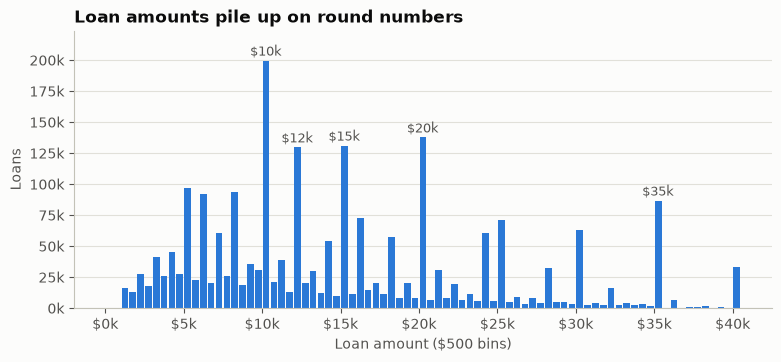

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.6))
counts, edges, _ = ax.hist(y, bins=np.arange(0, 41_000, 500), color=BLUE, rwidth=0.85)
for amount in top_amounts.index:
    ax.text(amount + 250, counts[int(amount // 500)] + 4000, f"${amount / 1000:.0f}k", ha="center", color=INK2, fontsize=9)
ax.set_ylim(0, counts.max() * 1.12)
ax.set_title("Loan amounts pile up on round numbers")
ax.set_xlabel("Loan amount ($500 bins)")
ax.set_ylabel("Loans")
ax.xaxis.set_major_formatter(lambda v, _: f"${v / 1000:.0f}k")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f}k")
ax.grid(axis="x", visible=False)
save(fig, "03_target_distribution.png")
plt.show()

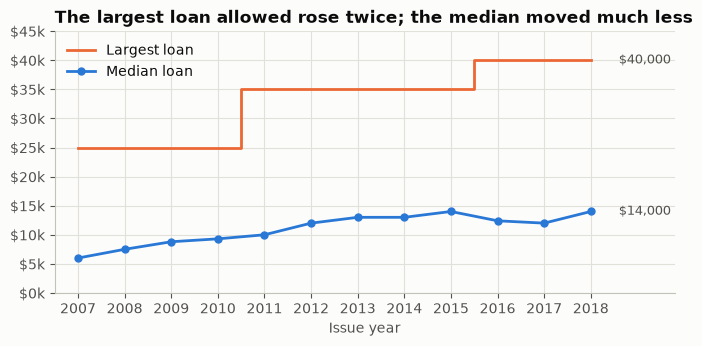

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.step(by_year.index, by_year["max"], where="mid", color=ORANGE, lw=2, label="Largest loan")
ax.plot(by_year.index, by_year["median"], color=BLUE, lw=2, marker="o", ms=5, label="Median loan")
last = by_year.index[-1]
ax.text(last + 0.6, by_year["max"].iloc[-1], f"${by_year['max'].iloc[-1]:,.0f}", va="center", color=INK2, fontsize=9)
ax.text(last + 0.6, by_year["median"].iloc[-1], f"${by_year['median'].iloc[-1]:,.0f}", va="center", color=INK2, fontsize=9)
ax.set_title("The largest loan allowed rose twice; the median moved much less")
ax.set_xlabel("Issue year")
ax.set_xticks(by_year.index)
ax.set_xlim(by_year.index[0] - 0.5, last + 1.8)
ax.set_ylim(0, 45_000)
ax.yaxis.set_major_formatter(lambda v, _: f"${v / 1000:.0f}k")
ax.legend(loc="upper left")
save(fig, "03_loan_cap_by_year.png")
plt.show()

- The distribution is not smooth. It is a row of spikes on round numbers: \$10,000 alone is 8% of all loans, and about 70% of loans are an exact multiple of \$1,000.
- The right edge is a wall, not a tail. It is LendingClub's maximum, which moved from \$25,000 to \$35,000 (first seen February 2011) and to \$40,000 (first seen March 2016).
- The target has no missing values and no impossible values, so it needs no cleaning.

**For cleaning:** leave `loan_amnt` exactly as it is. **For modelling (step 6 onward):** the spikes and the moving cap are properties of the problem, and issue year has to be available as a feature. The cleaned file keeps `issue_d` and adds `issue_year`.

### 3.6 Text columns that need parsing

In [22]:
n_unique = df.nunique()  # distinct non-missing values per column; reused in 3.7 and step 4

parse_cols = ["term", "emp_length", "issue_d", "earliest_cr_line", "zip_code", "home_ownership", "emp_title", "title"]
pd.DataFrame({
    "stored as": df[parse_cols].dtypes.astype(str),
    "distinct values": n_unique[parse_cols],
    "% missing": null_pct_raw[parse_cols].round(1),
    "examples": [", ".join(repr(v) for v in df[c].dropna().unique()[:3]) for c in parse_cols],
})

,stored as,distinct values,% missing,examples
term,str,2,0.0,"' 36 months', ' 60 months'"
emp_length,str,11,6.5,"'10+ years', '3 years', '4 years'"
issue_d,str,139,0.0,"'Dec-2015', 'Nov-2015', 'Oct-2015'"
earliest_cr_line,str,754,0.0,"'Aug-2003', 'Dec-1999', 'Aug-2000'"
zip_code,str,956,0.0,"'190xx', '577xx', '605xx'"
home_ownership,str,6,0.0,"'MORTGAGE', 'RENT', 'OWN'"
emp_title,str,512694,7.4,"'leadman', 'Engineer', 'truck driver'"
title,str,63154,1.0,"'Debt consolidation', 'Business', 'Major purchase'"


In [23]:
pd.concat({
    "emp_length": df.loc[loans, "emp_length"].value_counts(dropna=False),
    "home_ownership": df.loc[loans, "home_ownership"].value_counts(),
}).rename("loans").to_frame()

loans
emp_length     10+ years   748005
               2 years     203677
               < 1 year    189988
               3 years     180753
               1 year      148403
               nan         146907
               5 years     139698
               4 years     136605
               6 years     102628
               7 years      92695
               8 years      91914
               9 years      79395
home_ownership MORTGAGE   1111450
               RENT        894929
               OWN         253057
               ANY            996
               OTHER          182
               NONE            54

- `term` is a number with a leading space and the word "months".
- `emp_length` is an ordered scale written as text, from "< 1 year" to "10+ years", and 6.5% of loans have none.
- `issue_d` and `earliest_cr_line` are month-year text.
- `zip_code` is masked to three digits by LendingClub, so it stays text.
- `home_ownership` has three rare labels (`ANY`, `OTHER`, `NONE`) covering about 1,200 loans.
- `emp_title` is typed by the borrower: over half a million distinct values, differing in case and spacing. `title` is free text too, and repeats `purpose`.

**For cleaning:** turn `term` and `emp_length` into numbers and the dates into dates; derive the length of credit history from the two dates; merge the rare `home_ownership` labels into `OTHER`; lower-case and trim `emp_title`; drop `title`.

### 3.7 Empty, constant and redundant columns, and leakage

In [24]:
constant_cols = n_unique[n_unique <= 1]
print("Empty or single-valued columns:")
print(constant_cols.rename("distinct values").to_string())

fico_gap = (df["fico_range_high"] - df["fico_range_low"]).value_counts()
print(f"\nfico_range_high minus fico_range_low: {fico_gap.to_dict()}")

funded_same_pct = df.loc[loans, "funded_amnt"].eq(y).mean() * 100
print(f"\nfunded_amnt equals loan_amnt in {funded_same_pct:.2f}% of loans")
leak_corr = df[["funded_amnt", "funded_amnt_inv", "installment", "int_rate", "annual_inc", "fico_range_low"]].corrwith(df[TARGET])
leak_corr.round(3).rename("correlation with loan_amnt").to_frame()

Empty or single-valued columns:
member_id          0
policy_code        1
hardship_type      1
deferral_term      1
hardship_length    1

fico_range_high minus fico_range_low: {4.0: 2260227, 5.0: 441}

funded_amnt equals loan_amnt in 99.91% of loans


,correlation with loan_amnt
funded_amnt,1.000
funded_amnt_inv,0.999
installment,0.946
int_rate,0.098
annual_inc,0.197
fico_range_low,0.111


- Five columns carry no information: `member_id` is empty and four others hold a single value.
- `fico_range_high` is always `fico_range_low` plus 4 or 5, so one of the two is enough.
- `funded_amnt`, `funded_amnt_inv` and `installment` are the target restated (correlation 0.95 to 1.00). A model given these would look perfect and be useless. For comparison, income, a genuine application-time feature, correlates at about 0.2.

**For cleaning:** drop the empty and constant columns and `fico_range_high`. The leakage columns are **not** dropped here. They are tagged, and the drop decision is taken in step 7 with the feature selection.

### 3.8 Complexity scorecard (completes 1.8)

In [25]:
scorecard = pd.DataFrame([
    ("Volume and width", f"{n_rows_raw:,} rows x {n_cols_raw} columns; {mem_gb_raw:.1f} GB in memory", "2"),
    ("Summary rows mixed into the data", f"{n_summary_rows} rows that are not loans", "4.1"),
    ("Missing values with structure", f"{n_above} of {n_cols_raw} columns more than {THRESHOLD}% empty; none between {largest_kept:.0f}% and {smallest_dropped:.0f}%", "4.3"),
    ("Fields added over time", f"open_acc_6m is {miss_by_year.loc['open_acc_6m', 2014]:.0f}% empty in 2014 and {miss_by_year.loc['open_acc_6m', 2016]:.0f}% empty in 2016", "4.3"),
    ("Broken values in joint applications", f"{odd_values.loc['dti above 100', 'loans']:,} loans with DTI above 100, all of them joint applications", "4.2"),
    ("Numbers and dates stored as text", f"{int((kind == 'text').sum())} text columns; term, emp_length and the dates need parsing", "4.4"),
    ("High-cardinality free text", f"emp_title has {n_unique['emp_title']:,} distinct values", "4.4"),
    ("Extreme values", f"annual_inc up to {df['annual_inc'].max():,.0f}; dti up to {df['dti'].max():,.0f}; revol_util up to {df['revol_util'].max():,.0f}%", "4.2, 4.6"),
    ("Empty, constant and redundant columns", f"{len(constant_cols)} empty or single-valued columns; fico_range_high repeats fico_range_low", "4.3"),
    ("Heaped target", f"{share_1000:.0f}% of loans on an exact $1,000 multiple; {share_5000:.0f}% on a $5,000 multiple", "step 6"),
    ("Bounded target, and the bound moved", f"maximum $25,000 at first, $35,000 from {first_35k.strftime('%b %Y')}, $40,000 from {first_40k.strftime('%b %Y')}", "step 6"),
    ("Leakage", f"funded_amnt equals loan_amnt in {funded_same_pct:.1f}% of loans; installment correlates at {leak_corr['installment']:.2f}", "4.7 (tagged), step 7"),
    ("Drift over twelve years", f"{by_year['loans'].iloc[0]:,} loans in {by_year.index[0]}, {by_year['loans'].iloc[-1]:,} in {by_year.index[-1]}", "step 6"),
], columns=["Challenge", "Measured evidence", "Handled in"])

with pd.option_context("display.max_colwidth", None):
    display(scorecard)

,Challenge,Measured evidence,Handled in
0,Volume and width,"2,260,701 rows x 151 columns; 3.3 GB in memory",2
1,Summary rows mixed into the data,33 rows that are not loans,4.1
2,Missing values with structure,58 of 151 columns more than 30% empty; none between 13% and 38%,4.3
3,Fields added over time,open_acc_6m is 100% empty in 2014 and 0% empty in 2016,4.3
4,Broken values in joint applications,"2,561 loans with DTI above 100, all of them joint applications",4.2
5,Numbers and dates stored as text,"38 text columns; term, emp_length and the dates need parsing",4.4
6,High-cardinality free text,"emp_title has 512,694 distinct values",4.4
7,Extreme values,"annual_inc up to 110,000,000; dti up to 999; revol_util up to 892%","4.2, 4.6"
8,"Empty, constant and redundant columns",5 empty or single-valued columns; fico_range_high repeats fico_range_low,4.3
9,Heaped target,"70% of loans on an exact $1,000 multiple; 34% on a $5,000 multiple",step 6


### 3.9 From insight to cleaning action

| Seen in | Observation | Cleaning action (step 4) |
|---|---|---|
| 2.3 | 33 summary rows | Drop them |
| 2.4 | No duplicate ids | Check again, nothing to drop |
| 3.4 | Broken income and DTI in joint applications | Use the joint income and DTI for those loans |
| 3.7 | Empty and constant columns | Drop them |
| 3.2, 3.3 | 58 columns more than 30% empty, by design | Drop them |
| 3.6, 3.7 | `url`, `title`, `fico_range_high` repeat other columns | Drop them |
| 3.6 | Numbers and dates stored as text | Parse them; derive credit-history length |
| 3.3 | Small gaps in kept columns | Median for numbers, "unknown" for text |
| 3.4 | Extreme values in income, utilisation and revolving balance | Cap those three columns at the 99.9th percentile |
| 3.5 | Target is complete and valid | Leave it untouched |
| 3.7 | Leakage columns | Tag every column with its role; no drop |

## 4. Data cleaning

Every action below comes from an observation in sections 2 and 3 (table 3.9). The number of rows and columns is logged after each step, and the full log is shown at the end.

In [26]:
cleaning_log = []


def log_step(step, note=""):
    cleaning_log.append({"step": step, "rows": len(df), "columns": df.shape[1], "what changed": note})
    print(f"{step:<44} {len(df):>9,} rows  {df.shape[1]:>3} columns   {note}")


# Kept for the before/after charts in section 5.
miss_before = null_pct_raw.copy()
cells_missing_before = df.isna().loc[loans].values.mean() * 100
raw_outliers = df.loc[loans, OUTLIER_COLS].reset_index(drop=True)
raw_examples = df.loc[:2, ["term", "emp_length", "issue_d", "emp_title", "home_ownership"]].copy()

log_step("0. Raw file")

0. Raw file                                  2,260,701 rows  151 columns   


### 4.1 Drop the summary rows and check for duplicates

The 33 rows without a loan amount are the quarterly totals lines (2.3). With them gone, `id` holds only numbers, so it is converted from text to an integer.

In [27]:
df = df[df[TARGET].notna()].reset_index(drop=True)
del not_loan, loans, issue_date, is_joint, checks  # masks built on the raw row order; no longer valid

assert not df["id"].duplicated().any(), "duplicate loan ids"
df["id"] = df["id"].astype("int64")
log_step("1. Drop summary rows", f"{n_summary_rows} rows removed; no duplicate ids")

1. Drop summary rows                         2,260,668 rows  151 columns   33 rows removed; no duplicate ids


### 4.2 Joint applications: use the joint income and DTI

For a joint application, LendingClub assessed the two borrowers together. The individual `annual_inc` and `dti` are then sometimes 0, 999 or empty (3.4), and `annual_inc_joint` and `dti_joint` hold the figures that were used. So for joint applications the joint value replaces the individual one. This has to happen before the joint columns are dropped in 4.3.

After this step `annual_inc` and `dti` mean "the income and DTI the application was assessed on" for every loan.

In [28]:
joint = df["application_type"].eq("Joint App")


def joint_fix_summary():
    return pd.Series({
        "annual_inc is 0": int(df["annual_inc"].eq(0).sum()),
        "dti above 100": int(df["dti"].gt(100).sum()),
        "dti below 0": int(df["dti"].lt(0).sum()),
        "dti missing": int(df["dti"].isna().sum()),
    })


before_fix = joint_fix_summary()
for own, joint_col in [("annual_inc", "annual_inc_joint"), ("dti", "dti_joint")]:
    use_joint = joint & df[joint_col].notna()
    df[own] = df[own].mask(use_joint, df[joint_col])
    print(f"{own}: joint value used for {int(use_joint.sum()):,} loans")

# A negative DTI is not possible; treat it as missing.
df["dti"] = df["dti"].mask(df["dti"] < 0)

log_step("2. Joint income and DTI for joint loans", f"{int(joint.sum()):,} joint applications")
pd.DataFrame({"before": before_fix, "after": joint_fix_summary()})

annual_inc: joint value used for 120,710 loans
dti: joint value used for 120,706 loans
2. Joint income and DTI for joint loans      2,260,668 rows  151 columns   120,710 joint applications


,before,after
annual_inc is 0,1667,0
dti above 100,2561,0
dti below 0,2,0
dti missing,1711,1


### 4.3 Drop columns that cannot be used

Three kinds of column go, in this order:

1. **Empty or single-valued** (3.7). They cannot tell two loans apart.
2. **More than 30% missing** (3.2, 3.3). These are the joint, hardship and settlement details, the credit-bureau block that only exists from December 2015, and the mostly-empty "months since" columns. Filling a third or more of a column with a made-up value would create data, not clean it.
3. **Redundant.** `url` is the loan id inside a web address, `title` is free text that repeats `purpose`, and `fico_range_high` is `fico_range_low` plus 4 or 5.

In [29]:
drop_constant = list(constant_cols.index)
df = df.drop(columns=drop_constant)
log_step("3. Drop empty and constant columns", ", ".join(drop_constant))

null_pct = df.isna().mean().mul(100)
drop_missing = list(null_pct[null_pct > THRESHOLD].sort_values(ascending=False).index)
df = df.drop(columns=drop_missing)
log_step(f"4. Drop columns over {THRESHOLD}% missing", f"{len(drop_missing)} columns")

drop_redundant = ["url", "title", "fico_range_high"]
df = df.drop(columns=drop_redundant)
log_step("5. Drop redundant columns", ", ".join(drop_redundant))

print(f"\nMost-missing column that is kept: {null_pct[null_pct <= THRESHOLD].idxmax()} ({null_pct[null_pct <= THRESHOLD].max():.1f}%)")
print(f"\nColumns dropped for missing values, by group:")
print(group_of[drop_missing].value_counts().to_string())
print()
for name in drop_missing:
    print(f"  {null_pct[name]:5.1f}%  {name}")

3. Drop empty and constant columns           2,260,668 rows  146 columns   member_id, policy_code, hardship_type, deferral_term, hardship_length


4. Drop columns over 30% missing             2,260,668 rows   92 columns   54 columns
5. Drop redundant columns                    2,260,668 rows   89 columns   url, title, fico_range_high

Most-missing column that is kept: mths_since_recent_inq (13.1%)

Columns dropped for missing values, by group:
group
Credit bureau file          19
Joint / second applicant    16
Hardship plan               11
Debt settlement              6
Loan terms and listing       1
Post-issue performance       1

   99.6%  orig_projected_additional_accrued_interest
   99.5%  hardship_start_date
   99.5%  hardship_dpd
   99.5%  payment_plan_start_date
   99.5%  hardship_reason
   99.5%  hardship_amount
   99.5%  hardship_end_date
   99.5%  hardship_last_payment_amount
   99.5%  hardship_payoff_balance_amount
   99.5%  hardship_loan_status
   99.5%  hardship_status
   98.5%  settlement_percentage
   98.5%  debt_settlement_flag_date
   98.5%  settlement_status
   98.5%  settlement_date
   98.5%  settlement_amount

### 4.4 Parse text into numbers and dates

- `term`: `" 36 months"` becomes the number 36.
- `emp_length`: `"< 1 year"` becomes 0, `"1 year"` to `"9 years"` become 1 to 9, and `"10+ years"` becomes 10. So 10 means "ten or more". The check below fails if the column holds any label that is not in the mapping.
- Dates: `"Dec-2015"` becomes a real date (the first of the month).
- Two derived columns:
  - `issue_year`, needed because the loan cap and the borrower mix change over time (3.5);
  - `credit_history_years`, the time from the borrower's first credit line to the issue date. This replaces `earliest_cr_line`, which a model cannot use as a raw date.
- `emp_title`: trimmed and lower-cased, so that "Teacher", "teacher" and "teacher " count as one.
- `home_ownership`: the rare labels `ANY` and `NONE` are merged into `OTHER`.

In [30]:
df["term"] = df["term"].str.extract(r"(\d+)")[0].astype("int16")

EMP_YEARS = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4, "5 years": 5,
             "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10}
unmapped = set(df["emp_length"].dropna().unique()) - set(EMP_YEARS)
assert not unmapped, f"emp_length labels without a mapping: {unmapped}"
df["emp_length"] = df["emp_length"].map(EMP_YEARS).astype("float64")

for c in ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]:
    df[c] = pd.to_datetime(df[c], format="%b-%Y")

df["issue_year"] = df["issue_d"].dt.year.astype("int16")
df["credit_history_years"] = ((df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25).round(1)
df = df.drop(columns="earliest_cr_line")

emp_titles_before = n_unique["emp_title"]
df["emp_title"] = df["emp_title"].str.strip().str.lower()
df["home_ownership"] = df["home_ownership"].replace({"ANY": "OTHER", "NONE": "OTHER"})

log_step("6. Parse text; derive 2 columns", "+issue_year, +credit_history_years, -earliest_cr_line")
print(f"\nterm values            : {sorted(df['term'].unique().tolist())}")
print(f"emp_length values      : {sorted(df['emp_length'].dropna().unique().tolist())}")
print(f"issue_d range          : {df['issue_d'].min():%Y-%m-%d} to {df['issue_d'].max():%Y-%m-%d}")
print(f"credit_history_years   : {df['credit_history_years'].min()} to {df['credit_history_years'].max()}, median {df['credit_history_years'].median()}")
print(f"emp_title distinct     : {emp_titles_before:,} before, {df['emp_title'].nunique():,} after")
print(f"home_ownership         : {df['home_ownership'].value_counts().to_dict()}")

6. Parse text; derive 2 columns              2,260,668 rows   90 columns   +issue_year, +credit_history_years, -earliest_cr_line

term values            : [36, 60]
emp_length values      : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
issue_d range          : 2007-06-01 to 2018-12-01
credit_history_years   : 0.5 to 83.3, median 14.8


emp_title distinct     : 512,694 before, 411,810 after
home_ownership         : {'MORTGAGE': 1111450, 'RENT': 894929, 'OWN': 253057, 'OTHER': 1232}


### 4.5 Fill the remaining missing values

After 4.3 no column is more than about 13% empty. What is left is filled with one simple rule per type:

- **Numbers: the column median.** The median is used, not the mean, because many of these columns are skewed (3.4) and the mean would be pulled by the extremes.
- **Text: the label `unknown`.** A missing job title is itself information (no employer given), so it gets its own label and is not guessed.
- **Dates: left empty.** The only dates with gaps are `last_pymnt_d` and `last_credit_pull_d`, which are post-issue fields. A loan with no payment has no last-payment date, and inventing one would be wrong.

In [31]:
missing_before_fill = df.isna().sum()
num_cols = df.select_dtypes("number").columns
text_cols = df.select_dtypes(exclude=["number", "datetime"]).columns

medians = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(medians)
df[text_cols] = df[text_cols].fillna("unknown")

filled = missing_before_fill[missing_before_fill > 0].sort_values(ascending=False)
fill_table = pd.DataFrame({
    "cells missing": filled,
    "% of loans": (filled / len(df) * 100).round(2),
    "filled with": [f"median = {medians[c]:,.1f}" if c in num_cols else ("unknown" if c in text_cols else "left empty")
                    for c in filled.index],
})
cells_filled = int(filled[[c for c in filled.index if c in num_cols or c in text_cols]].sum())
log_step("7. Fill missing values", f"{cells_filled:,} cells in {len(filled)} columns")
fill_table

7. Fill missing values                       2,260,668 rows   90 columns   2,998,961 cells in 54 columns


,cells missing,% of loans,filled with
mths_since_recent_inq,295435,13.07,median = 5.0
emp_title,166969,7.39,unknown
num_tl_120dpd_2m,153657,6.80,median = 0.0
emp_length,146907,6.50,median = 6.0
mo_sin_old_il_acct,139071,6.15,median = 130.0
bc_util,76071,3.36,median = 60.2
percent_bc_gt_75,75379,3.33,median = 37.5
bc_open_to_buy,74935,3.31,"median = 5,442.0"
mths_since_recent_bc,73412,3.25,median = 14.0
pct_tl_nvr_dlq,70431,3.12,median = 100.0


Two things to know about the filled values:

- About 3% of loans (those issued before mid-2012) have a median in every credit-bureau column that LendingClub only started recording in 2012. For those loans the values are placeholders, not measurements.
- `mths_since_recent_inq` is the most-filled column. An empty value there means "no recent inquiry", so the median understates how clean those borrowers are. Step 7 may prefer to treat it differently.

### 4.6 Cap extreme values

`annual_inc`, `revol_util` and `revol_bal` are capped at their 99.9th percentile (3.4).

- **Why cap and not delete:** each row is a real loan with a valid target. Deleting it would lose that loan because of one bad field.
- **Why 99.9% and not 99%:** a tighter cap would flatten real high earners. At 99.9% the cap touches one loan in a thousand.
- **Why not `dti`:** its impossible values were all in joint applications and were fixed in 4.2. What is left tops out near 70, which is a real joint DTI, so a cap would cut into genuine values. The cell prints its range to confirm.
- **Why only these three:** they are the ones whose extremes are clearly errors or freak values and that are likely model features. Other columns are left as recorded.

In [32]:
CAP_COLS = ["annual_inc", "revol_util", "revol_bal"]
caps = df[CAP_COLS].quantile(0.999)
cap_table = pd.DataFrame({
    "max before": df[CAP_COLS].max(),
    "cap (99.9th percentile)": caps,
    "loans capped": (df[CAP_COLS] > caps).sum(),
})
df[CAP_COLS] = df[CAP_COLS].clip(upper=caps, axis=1)
cap_table["max after"] = df[CAP_COLS].max()

log_step("8. Cap 3 columns at the 99.9th percentile", f"{int(cap_table['loans capped'].sum()):,} values capped")
print(f"\ndti, not capped: min {df['dti'].min():.1f}, 99.9th percentile {df['dti'].quantile(0.999):.1f}, max {df['dti'].max():.1f}")
cap_table.round(1)

8. Cap 3 columns at the 99.9th percentile    2,260,668 rows   90 columns   6,771 values capped

dti, not capped: min 0.0, 99.9th percentile 40.7, max 69.5


,max before,cap (99.9th percentile),loans capped,max after
annual_inc,110000000.0,611024.4,2261,611024.4
revol_util,892.3,102.1,2249,102.1
revol_bal,2904836.0,265894.3,2261,265894.3


### 4.7 Tag every column with its role

Nothing is dropped for leakage here. Each column gets one of six roles, so that feature selection in step 7 starts from an explicit list:

| Role | Meaning | Use as a model feature? |
|---|---|---|
| `id` | Loan identifier | No |
| `target` | `loan_amnt` | It is what we predict |
| `leakage` | Restates the target (`funded_amnt`, `funded_amnt_inv`, `installment`) | Never |
| `post_issue` | Only exists after the loan is issued (status, payments, recoveries) | Never |
| `lc_pricing` | Set by LendingClub when it prices and lists the loan (term, rate, grade) | Only in feature set B, and with care: partly circular |
| `application` | Known when the borrower applies | Yes (feature set A) |

The check fails if any column is left without a role or is given two. Low-cardinality text columns are also stored as categories, which makes the file smaller and tells Tableau and pandas they are labels.

In [33]:
for c in df.select_dtypes(exclude=["number", "datetime"]).columns:
    if df[c].nunique() <= 60:
        df[c] = df[c].astype("category")

group_clean = group_of.reindex(df.columns)
group_clean["issue_year"] = "Loan terms and listing"
group_clean["credit_history_years"] = "Credit bureau file"

ROLES = {
    "id": ["id"],
    "target": [TARGET],
    "leakage": ["funded_amnt", "funded_amnt_inv", "installment"],
    "lc_pricing": ["term", "int_rate", "grade", "sub_grade", "initial_list_status", "disbursement_method"],
    "post_issue": [c for c in df.columns if group_clean[c] == "Post-issue performance"] + ["hardship_flag", "debt_settlement_flag"],
    "application": [c for c in df.columns if group_clean[c] in ("Borrower profile", "Credit bureau file")]
                   + ["issue_d", "issue_year", "purpose", "application_type"],
}
tagged = [c for members in ROLES.values() for c in members]
untagged = [c for c in df.columns if c not in tagged]
tagged_twice = sorted({c for c in tagged if tagged.count(c) > 1})
not_in_table = [c for c in tagged if c not in df.columns]
print(f"Columns tagged: {len(tagged)} of {df.shape[1]} | untagged: {untagged} | tagged twice: {tagged_twice} | not in table: {not_in_table}")
assert not untagged and not tagged_twice and not not_in_table

role_of = {c: role for role, members in ROLES.items() for c in members}
column_tags = pd.DataFrame({
    "column": df.columns,
    "role": [role_of[c] for c in df.columns],
    "group": group_clean.values,
    "dtype": df.dtypes.astype(str).values,
})
column_tags.to_csv(TAGS_PATH, index=False)
log_step("9. Tag columns; store labels as categories", f"roles written to {TAGS_PATH.relative_to(ROOT).as_posix()}")
column_tags["role"].value_counts().to_frame("columns")

Columns tagged: 90 of 90 | untagged: [] | tagged twice: [] | not in table: []
9. Tag columns; store labels as categories   2,260,668 rows   90 columns   roles written to outputs/column_tags.csv


,columns
role,
application,61
post_issue,18
lc_pricing,6
leakage,3
id,1
target,1


### 4.8 Save and check

In [34]:
df.to_parquet(CLEAN_PATH, index=False)

still_missing = df.isna().sum()
still_missing = still_missing[still_missing > 0]
assert len(df) == n_rows_raw - n_summary_rows
assert set(still_missing.index) <= {"last_pymnt_d", "last_credit_pull_d"}

print(f"Written: {CLEAN_PATH.relative_to(ROOT).as_posix()} ({CLEAN_PATH.stat().st_size / 1e6:,.0f} MB)")
print(f"Columns that still have missing values: {still_missing.to_dict()}")
cleaning_log_table = pd.DataFrame(cleaning_log)
with pd.option_context("display.max_colwidth", None):
    display(cleaning_log_table)

Written: data/processed/loans_clean.parquet (275 MB)
Columns that still have missing values: {'last_pymnt_d': 2427, 'last_credit_pull_d': 72}


,step,rows,columns,what changed
0,0. Raw file,2260701,151,
1,1. Drop summary rows,2260668,151,33 rows removed; no duplicate ids
2,2. Joint income and DTI for joint loans,2260668,151,"120,710 joint applications"
3,3. Drop empty and constant columns,2260668,146,"member_id, policy_code, hardship_type, deferral_term, hardship_length"
4,4. Drop columns over 30% missing,2260668,92,54 columns
5,5. Drop redundant columns,2260668,89,"url, title, fico_range_high"
6,6. Parse text; derive 2 columns,2260668,90,"+issue_year, +credit_history_years, -earliest_cr_line"
7,7. Fill missing values,2260668,90,"2,998,961 cells in 54 columns"
8,8. Cap 3 columns at the 99.9th percentile,2260668,90,"6,771 values capped"
9,9. Tag columns; store labels as categories,2260668,90,roles written to outputs/column_tags.csv


The row count changes once (the 33 summary rows) and never again: no loan is deleted by the cleaning. The two columns that still have empty cells are the post-issue dates left empty on purpose (4.5).

## 5. Before and after cleaning

Everything labelled "after" in this section is read back from the saved parquet file, not taken from the table in memory. The charts therefore show what a teammate will actually load.

In [35]:
import gc

del df
gc.collect()

clean = pd.read_parquet(CLEAN_PATH)
miss_after = clean.isna().mean().mul(100)
print(f"Reloaded {CLEAN_PATH.relative_to(ROOT).as_posix()}: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

Reloaded data/processed/loans_clean.parquet: 2,260,668 rows x 90 columns


### 5.1 The table before and after

In [36]:
is_num = clean.dtypes.map(pd.api.types.is_numeric_dtype)
is_date = clean.dtypes.map(pd.api.types.is_datetime64_any_dtype)
is_cat = clean.dtypes.map(lambda t: isinstance(t, pd.CategoricalDtype))

before_after = pd.DataFrame({
    "before": {
        "rows": f"{n_rows_raw:,}",
        "columns": f"{n_cols_raw}",
        "numeric columns": f"{int((kind == 'numeric').sum())}",
        "date columns": "0",
        "category columns": "0",
        "free-text columns": f"{int((kind == 'text').sum())}",
        "columns with missing values": f"{int((miss_before > 0).sum())}",
        "cells missing": f"{cells_missing_before:.1f}%",
        "in memory": f"{mem_gb_raw:.2f} GB",
        "file on disk": f"{DATA_PATH.stat().st_size / 1e6:,.0f} MB (csv.gz)",
    },
    "after": {
        "rows": f"{len(clean):,}",
        "columns": f"{clean.shape[1]}",
        "numeric columns": f"{int(is_num.sum())}",
        "date columns": f"{int(is_date.sum())}",
        "category columns": f"{int(is_cat.sum())}",
        "free-text columns": f"{int((~is_num & ~is_date & ~is_cat).sum())}",
        "columns with missing values": f"{int((miss_after > 0).sum())}",
        "cells missing": f"{clean.isna().values.mean() * 100:.3f}%",
        "in memory": f"{clean.memory_usage(deep=True).sum() / 1e9:.2f} GB",
        "file on disk": f"{CLEAN_PATH.stat().st_size / 1e6:,.0f} MB (parquet)",
    },
})
before_after

,before,after
rows,"2,260,701","2,260,668"
columns,151,90
numeric columns,113,72
date columns,0,3
category columns,0,13
free-text columns,38,2
columns with missing values,113,2
cells missing,31.8%,0.001%
in memory,3.29 GB,1.44 GB
file on disk,393 MB (csv.gz),275 MB (parquet)


- The 33 summary rows are gone and the table is 61 columns narrower; every loan is still there.
- 38 text columns became 3 dates, 13 categories and 2 free-text columns (`emp_title`, `zip_code`). The rest were parsed into numbers or dropped.
- Almost a third of all cells were empty before. Now the only empty cells are in two post-issue date columns, left empty on purpose.
- The table takes less than half the memory, and the parquet file keeps the column types, so nothing has to be parsed again on load.

### 5.2 Missing values

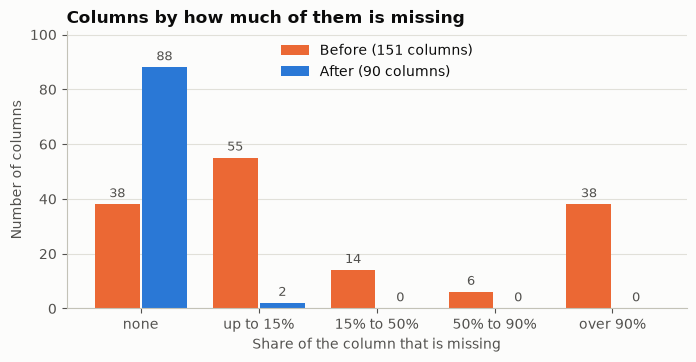

,before,after
none,38,88
up to 15%,55,2
15% to 50%,14,0
50% to 90%,6,0
over 90%,38,0


In [37]:
bands_after = pd.cut(miss_after, BAND_EDGES, labels=BAND_LABELS).value_counts().reindex(BAND_LABELS)

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(BAND_LABELS))
w = 0.38
b_before = ax.bar(x - w / 2 - 0.01, bands_before.values, w, color=ORANGE, label=f"Before ({n_cols_raw} columns)")
b_after = ax.bar(x + w / 2 + 0.01, bands_after.values, w, color=BLUE, label=f"After ({clean.shape[1]} columns)")
ax.bar_label(b_before, padding=3, color=INK2, fontsize=9)
ax.bar_label(b_after, padding=3, color=INK2, fontsize=9)
ax.set_xticks(x, BAND_LABELS)
ax.set_title("Columns by how much of them is missing")
ax.set_xlabel("Share of the column that is missing")
ax.set_ylabel("Number of columns")
ax.set_ylim(0, max(bands_before.max(), bands_after.max()) * 1.15)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center")
save(fig, "05_missing_before_after.png")
plt.show()

pd.DataFrame({"before": bands_before, "after": bands_after})

Before, 58 columns were more than 30% empty and only 38 were complete. After, 88 of 90 columns are complete, and the two that are not are the post-issue dates.

### 5.3 Extreme values

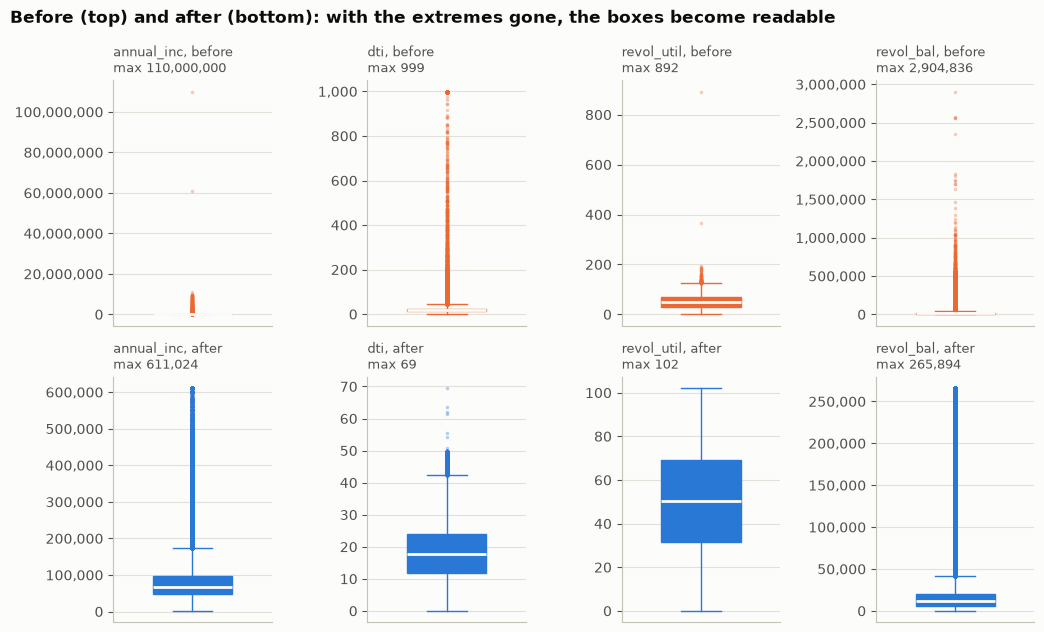

,max before,max after,median before,median after,mean before,mean after
annual_inc,110000000.0,611024.4,65000.0,68500.0,77992.4,80660.9
dti,999.0,69.5,17.8,17.7,18.8,18.2
revol_util,892.3,102.1,50.3,50.3,50.3,50.3
revol_bal,2904836.0,265894.3,11324.0,11324.0,16658.5,16533.8


In [38]:
fig, axes = plt.subplots(2, len(OUTLIER_COLS), figsize=(10.5, 6.4))
for j, c in enumerate(OUTLIER_COLS):
    for i, (label, values, color) in enumerate([("before", raw_outliers[c].dropna(), ORANGE), ("after", clean[c], BLUE)]):
        ax = axes[i, j]
        draw_box(ax, values, color)
        ax.set_title(f"{c}, {label}\nmax {values.max():,.0f}", fontsize=9.5, color=INK2, fontweight="normal")
fig.suptitle("Before (top) and after (bottom): with the extremes gone, the boxes become readable",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "05_outliers_before_after.png")
plt.show()

pd.DataFrame({
    "max before": raw_outliers.max(), "max after": clean[OUTLIER_COLS].max(),
    "median before": raw_outliers.median(), "median after": clean[OUTLIER_COLS].median(),
    "mean before": raw_outliers.mean(), "mean after": clean[OUTLIER_COLS].mean(),
}).round(1)

- **Before:** each box is squashed against the bottom because the axis has to reach a few extreme points.
- **After:** the box, the median line and the whiskers are visible, so the charts now describe the typical borrower.
- `annual_inc`, `revol_util` and `revol_bal` changed because of the cap (4.6). `dti` changed because joint applications now use the joint DTI (4.2); it was not capped.
- The medians barely move, which is the point: the cleaning changed the extremes and left the bulk of the data alone. The one exception is `annual_inc`, whose median rises because joint applications now carry the combined income of both borrowers.

### 5.4 Cleaning funnel

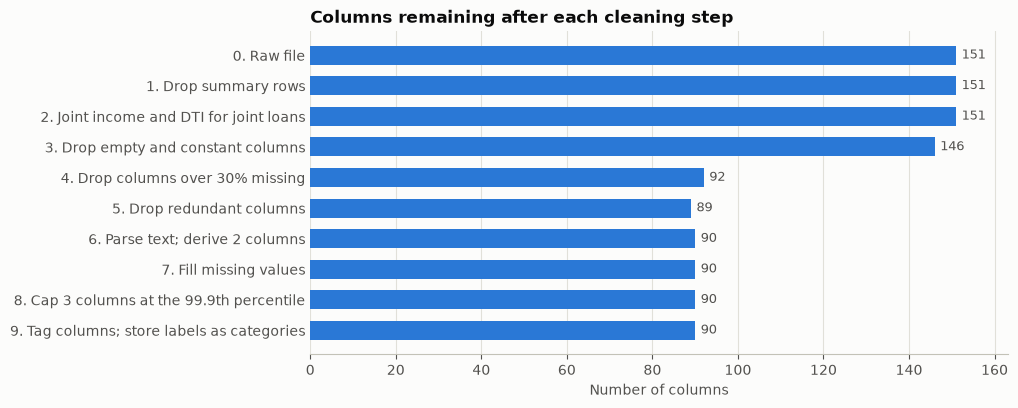

,step,rows,columns
0,0. Raw file,2260701,151
1,1. Drop summary rows,2260668,151
2,2. Joint income and DTI for joint loans,2260668,151
3,3. Drop empty and constant columns,2260668,146
4,4. Drop columns over 30% missing,2260668,92
5,5. Drop redundant columns,2260668,89
6,6. Parse text; derive 2 columns,2260668,90
7,7. Fill missing values,2260668,90
8,8. Cap 3 columns at the 99.9th percentile,2260668,90
9,9. Tag columns; store labels as categories,2260668,90


In [39]:
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(cleaning_log_table["step"], cleaning_log_table["columns"], color=BLUE, height=0.62)
ax.bar_label(bars, padding=4, color=INK2, fontsize=9)
ax.invert_yaxis()
ax.set_title("Columns remaining after each cleaning step")
ax.set_xlabel("Number of columns")
ax.set_xlim(0, n_cols_raw * 1.08)
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "05_cleaning_funnel.png")
plt.show()

cleaning_log_table[["step", "rows", "columns"]]

The big drop is step 4, the columns that are mostly empty. The row count changes only at step 1.

### 5.5 Text turned into usable types

The same three loans, before and after.

In [40]:
shown = list(raw_examples.columns)
pd.DataFrame({
    "before": [", ".join(repr(v) for v in raw_examples[c]) for c in shown],
    "after": [", ".join(str(v) for v in clean.loc[:2, c]) for c in shown],
    "type after": [str(clean[c].dtype) for c in shown],
}, index=shown)

,before,after,type after
term,"' 36 months', ' 36 months', ' 60 months'","36, 36, 60",int16
emp_length,"'10+ years', '10+ years', '10+ years'","10.0, 10.0, 10.0",float64
issue_d,"'Dec-2015', 'Dec-2015', 'Dec-2015'","2015-12-01 00:00:00, 2015-12-01 00:00:00, 2015-12-01 00:00:00",datetime64[us]
emp_title,"'leadman', 'Engineer', 'truck driver'","leadman, engineer, truck driver",str
home_ownership,"'MORTGAGE', 'MORTGAGE', 'MORTGAGE'","MORTGAGE, MORTGAGE, MORTGAGE",category


### 5.6 The target is untouched

In [41]:
target_unchanged = clean[TARGET].reset_index(drop=True).equals(y.reset_index(drop=True))
print(f"loan_amnt identical before and after, loan by loan: {target_unchanged}")
assert target_unchanged
pd.DataFrame({"before": y.describe(), "after": clean[TARGET].describe()}).round(1)

loan_amnt identical before and after, loan by loan: True


,before,after
count,2260668.0,2260668.0
mean,15046.9,15046.9
std,9190.2,9190.2
min,500.0,500.0
25%,8000.0,8000.0
50%,12900.0,12900.0
75%,20000.0,20000.0
max,40000.0,40000.0


### 5.7 What the cleaned file contains

In [42]:
for role, members in column_tags.groupby("role", sort=False)["column"]:
    print(f"{role} ({len(members)}):\n  {', '.join(members)}\n")

id (1):
  id

target (1):
  loan_amnt

leakage (3):
  funded_amnt, funded_amnt_inv, installment

lc_pricing (6):
  term, int_rate, grade, sub_grade, initial_list_status, disbursement_method

application (61):
  emp_title, emp_length, home_ownership, annual_inc, verification_status, issue_d, purpose, zip_code, addr_state, dti, delinq_2yrs, fico_range_low, inq_last_6mths, open_acc, pub_rec, revol_bal, revol_util, total_acc, collections_12_mths_ex_med, application_type, acc_now_delinq, tot_coll_amt, tot_cur_bal, total_rev_hi_lim, acc_open_past_24mths, avg_cur_bal, bc_open_to_buy, bc_util, chargeoff_within_12_mths, delinq_amnt, mo_sin_old_il_acct, mo_sin_old_rev_tl_op, mo_sin_rcnt_rev_tl_op, mo_sin_rcnt_tl, mort_acc, mths_since_recent_bc, mths_since_recent_inq, num_accts_ever_120_pd, num_actv_bc_tl, num_actv_rev_tl, num_bc_sats, num_bc_tl, num_il_tl, num_op_rev_tl, num_rev_accts, num_rev_tl_bal_gt_0, num_sats, num_tl_120dpd_2m, num_tl_30dpd, num_tl_90g_dpd_24m, num_tl_op_past_12m, pct_tl_n

### 5.8 Hand-off to steps 6 to 9

**Start from** `data/processed/loans_clean.parquet` (`pd.read_parquet`) and `outputs/column_tags.csv`. The parquet file is not in git; running this notebook re-creates it.

**Things to know before using the cleaned table**

- **Use the `role` column to pick features.** `application` columns are safe (feature set A). `lc_pricing` columns are set by LendingClub knowing the amount (feature set B, partly circular). `leakage` and `post_issue` columns must never be model features.
- **`annual_inc` and `dti` are the joint figures for joint applications** and the individual figures for everyone else. `application_type` says which is which.
- **Medians are placeholders for early loans.** Loans issued before mid-2012 (about 3% of rows) have a median in every credit-bureau column that did not exist yet. `issue_year` identifies them.
- **`emp_length` is in years, and 10 means ten or more.** The 6.5% of loans with no employment length were given the median.
- **`annual_inc`, `revol_util` and `revol_bal` are capped** at their 99.9th percentile.
- **`emp_title` still has over 400,000 distinct values.** It needs grouping before it can be used in a chart or a model. `zip_code` is a three-digit prefix stored as text.
- **The target is exactly as in the raw file.** It is heaped on round numbers and bounded by a cap that moved in 2011 and 2016 (3.5).